# <center>**Figure 3 : Supplementary Level 2 Innervation**</center>

In [1]:
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("ticks")
from prats_helpers import place_panel_label

In [2]:
linewidth      = 0.75
scatter_size   = 6
scatter_alpha  = 0.75
linewidth_hist = 0.5
alpha_hist     = 0.35
title_fontsize = 8.5
label_fontsize = 7
tick_fontsize  = 6
labelpad       = 10

# Labels
label_kwargs = dict(fontsize = 16, va = "top", ha = "left")

# Output Folder
FOLDER = "../Figures/Figure_03"
DATA   = "../Analysis_Outputs/Lineage_Innervation-Focusness"

In [3]:
comp_order_brain = np.load("../Data_Helpers/Relative_Compartment_Order_Level2.npy")
comp_order_vnc   = np.load("../Data_Helpers/Relative_Compartment_Order_Level2_VNC.npy")

In [4]:
# Inputs
psd_matrix = pd.read_parquet(f"{DATA}/Lineage_Innervation_PSDs_level2.parquet")
psd_matrix.set_index("Lineage", inplace = True)
psd_matrix_brain = psd_matrix.reindex(columns = comp_order_brain)
psd_matrix_vnc   = psd_matrix.reindex(columns = comp_order_vnc)

# Outputs
tbar_matrix = pd.read_parquet(f"{DATA}/Lineage_Innervation_TBars_level2.parquet")
tbar_matrix.set_index("Lineage", inplace = True)
tbar_matrix_brain = tbar_matrix.reindex(columns = comp_order_brain)
tbar_matrix_vnc   = tbar_matrix.reindex(columns = comp_order_vnc)

In [5]:
vmin, vmax = 0, 0.6

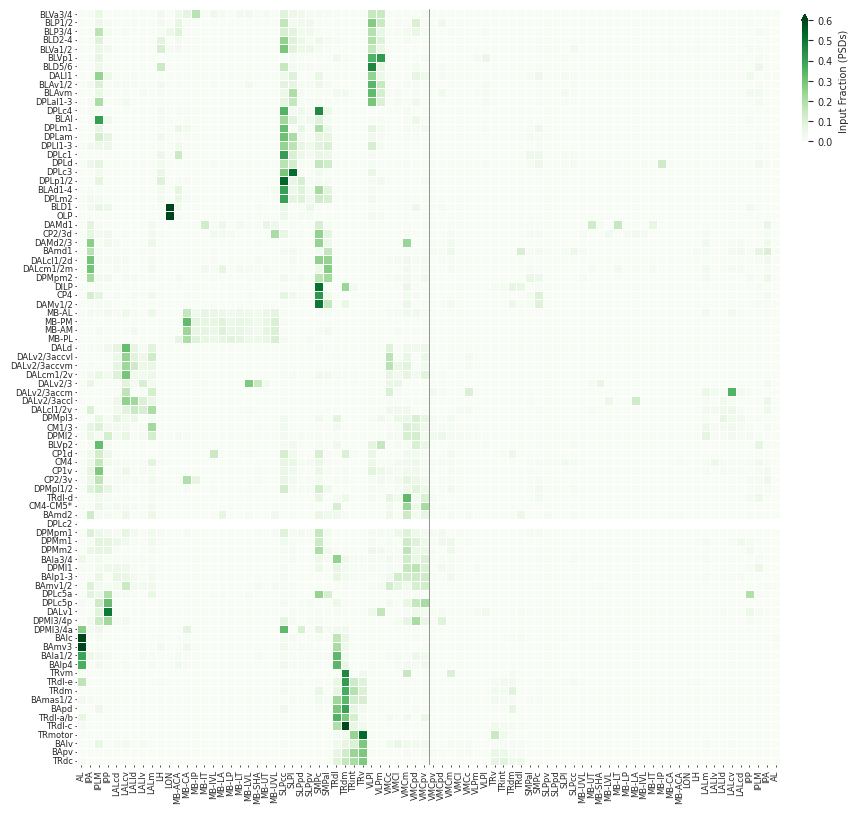

In [6]:
fig, ax = plt.subplots(figsize = (11, 11))

# Heatmap
sns.heatmap(psd_matrix_brain,
            cmap   = "Greens",
            square = True,
            ax     = ax,
            cbar_kws = {"shrink" : 0.15,
                        "extend" : "max",
                        "anchor" : (0, 0.93),
                        "label"  : "Input Fraction (PSDs)",
                        "pad"    : 0.025},
            xticklabels = True,
            yticklabels = True,
            linewidths = 0.6,
            vmin = vmin,
            vmax = vmax)

# Grids
ax.grid(False)
ax.invert_yaxis()
for s in ax.spines.values():
    s.set_color("black")
    s.set_linewidth(0.6)
    s.set_visible(True)

# C-BAR
cbar = ax.collections[0].colorbar
cbar.set_label("Input Fraction (PSDs)", size = label_fontsize)
cbar.ax.tick_params(labelsize = label_fontsize)

# Update the ticks
ax.tick_params(
    axis      = "both",
    which     = "major",
    color     = "black",
    labelsize = tick_fontsize,
    length    = 1.5,
    width     = 0.5,
    pad       = 1.5)

# Remove the X-label
ax.set_xlabel("")
ax.set_ylabel("")

# Update the bottom xticks to remove the Ipsi and Contra
new_labels  = [label.get_text().split("_")[0] for label in ax.get_xticklabels()]
# Re-apply
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(new_labels)

# Line
ax.axvline(x = 40, color = "black", linewidth = 0.5, alpha = 0.6)

# Despine
sns.despine(ax = ax, left = True, bottom = True)

#--------------------------------------------------------
# Save the Figure
plt.savefig(f"{FOLDER}/Figure_03_Supplementary-03_Level2-Innervation-PSDs.pdf",
            dpi = 1200,
            bbox_inches = "tight")

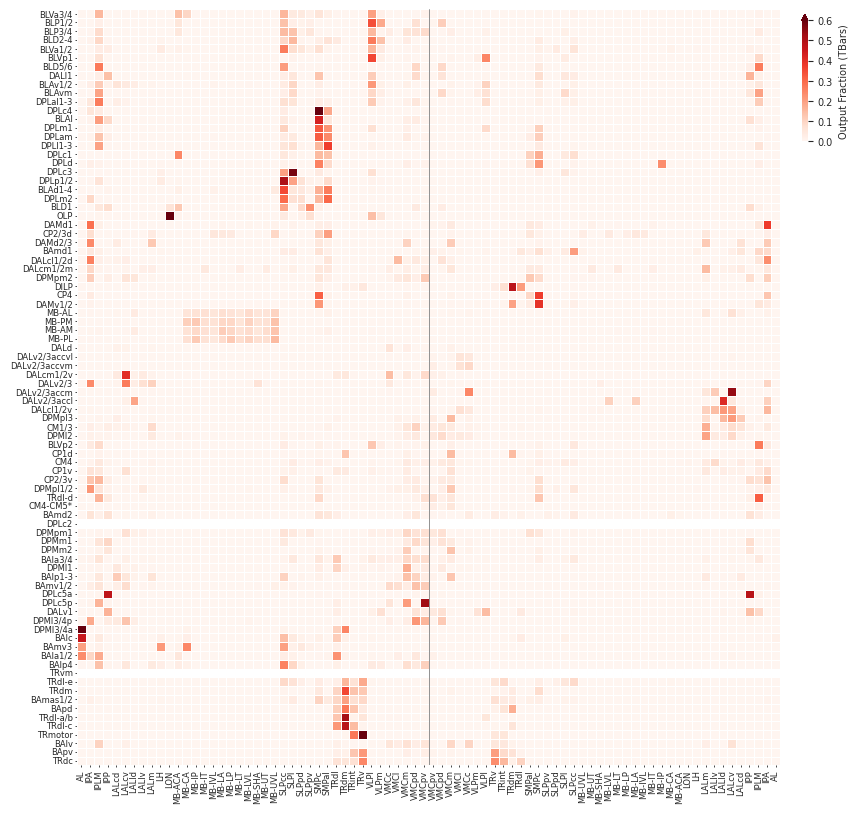

In [7]:
fig, ax = plt.subplots(figsize = (11, 11))

# Heatmap
sns.heatmap(tbar_matrix_brain,
            cmap   = "Reds",
            square = True,
            ax     = ax,
            cbar_kws = {"shrink" : 0.15,
                        "extend" : "max",
                        "anchor" : (0, 0.93),
                        "label"  : "Output Fraction (TBars)",
                        "pad"    : 0.025},
            xticklabels = True,
            yticklabels = True,
            linewidths = 0.6,
            vmin = vmin,
            vmax = vmax)

# Grids
ax.grid(False)
ax.invert_yaxis()
for s in ax.spines.values():
    s.set_color("black")
    s.set_linewidth(0.6)
    s.set_visible(True)

# C-BAR
cbar = ax.collections[0].colorbar
cbar.set_label("Output Fraction (TBars)", size = label_fontsize)
cbar.ax.tick_params(labelsize = label_fontsize)

# Update the ticks
ax.tick_params(
    axis      = "both",
    which     = "major",
    color     = "black",
    labelsize = tick_fontsize,
    length    = 1.5,
    width     = 0.5,
    pad       = 1.5)

# Remove the X-label
ax.set_xlabel("")
ax.set_ylabel("")

# Update the bottom xticks to remove the Ipsi and Contra
new_labels  = [label.get_text().split("_")[0] for label in ax.get_xticklabels()]
# Re-apply
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(new_labels)

# Line
ax.axvline(x = 40, color = "black", linewidth = 0.5, alpha = 0.6)

# Despine
sns.despine(ax = ax, left = True, bottom = True)

#--------------------------------------------------------
# Save the Figure
plt.savefig(f"{FOLDER}/Figure_03_Supplementary-04_Level2-Innervation-TBars.pdf",
            dpi = 1200,
            bbox_inches = "tight")

## VNC

In [8]:
vmax = 0.2

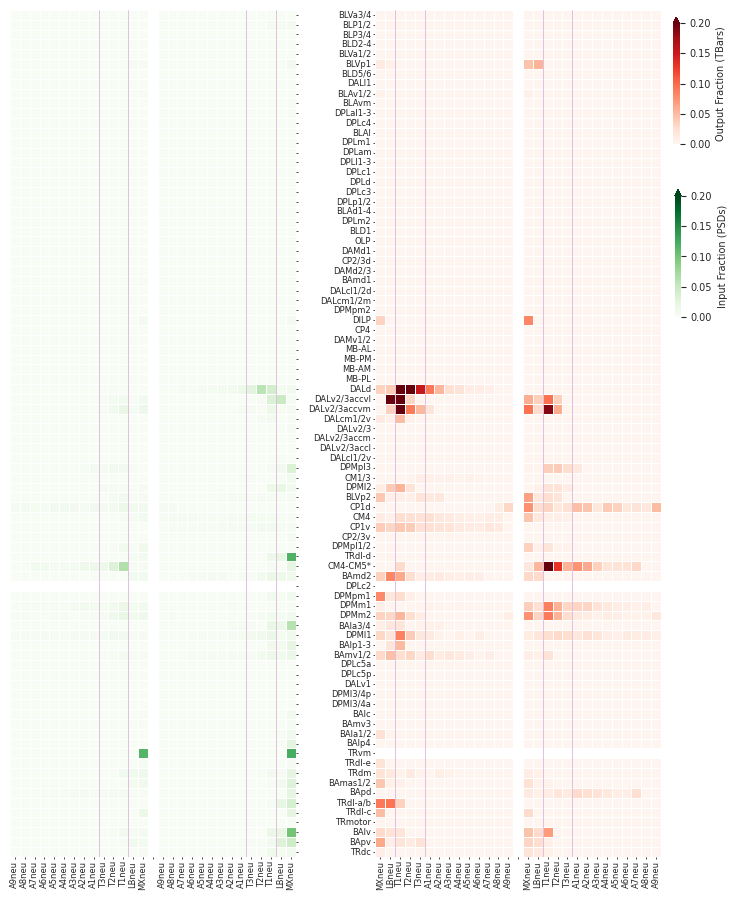

In [9]:
fig, ax = plt.subplots(figsize = (11, 11), ncols = 2, sharey = False)
plt.subplots_adjust(wspace = -0.25)

# Heatmap - Input
sns.heatmap(psd_matrix_vnc,
            cmap   = "Greens",
            square = True,
            ax     = ax[0],
            cbar_kws = {"shrink" : 0.15,
                        "extend" : "max",
                        "anchor" : (5.5, 0.75),
                        "label"  : "Input Fraction (PSDs)",
                        "pad"    : 0.025},
            xticklabels = True,
            yticklabels = True,
            linewidths = 0.6,
            vmin = vmin,
            vmax = vmax)

# Heatmap - Output
sns.heatmap(tbar_matrix_vnc,
            cmap   = "Reds",
            square = True,
            ax     = ax[1],
            cbar_kws = {"shrink" : 0.15,
                        "extend" : "max",
                        "anchor" : (0, 0.99),
                        "label"  : "Output Fraction (TBars)",
                        "pad"    : 0.025},
            xticklabels = True,
            yticklabels = True,
            linewidths = 0.6,
            vmin = vmin,
            vmax = vmax)

# Remove the yticks
ax[0].yaxis.tick_right()
ax[0].set_yticklabels([])
ax[0].invert_xaxis()

# Measures
meas = ["Input Fraction (PSDs)", "Output Fraction (TBars)"]
for i, a in enumerate(ax):
    # Change the CBar
    cbar = a.collections[0].colorbar
    cbar.set_label(meas[i], size = label_fontsize)
    cbar.ax.tick_params(labelsize = label_fontsize)
    # Remove Label
    a.set_ylabel("")
    a.set_xlabel("")
    a.grid(False)
    for s in a.spines.values():
        s.set_color("black")
        s.set_linewidth(0.6)
        s.set_visible(True)
        
    a.tick_params(
        axis      = "both",
        which     = "major",
        color     = "black",
        labelsize = tick_fontsize,
        length    = 1.5,
        width     = 0.5,
        pad       = 1.5)
    
    # Invert
    a.invert_yaxis()

    # Despine
    sns.despine(ax = a, bottom = True, left = True)

    # Update the bottom xticks to remove the Ipsi and Contra
    new_labels  = [label.get_text().split("_")[0] for label in a.get_xticklabels()]
    # Re-apply
    a.set_xticks(a.get_xticks())
    a.set_xticklabels(new_labels)

    # Lines separating the segments
    a.axvline(x = 2, linewidth = 0.5, color = "purple", alpha = 0.35)
    a.axvline(x = 5, linewidth = 0.5, color = "purple", alpha = 0.35)
    a.axvline(x = 17, linewidth = 0.5, color = "purple", alpha = 0.35)
    a.axvline(x = 20, linewidth = 0.5, color = "purple", alpha = 0.35)

#--------------------------------------------------------
# Save the Figure
plt.savefig(f"{FOLDER}/Figure_03_Supplementary-05_Level2-Innervation-VNC.pdf",
            dpi = 1200,
            bbox_inches = "tight")

# <center>**हो गया दोस्तों!**</center>